# Recommandations

Estimer les économies possibles sur les ressources « gaspillage » repérées à
l'étape 3, voir où elles se concentrent, et sortir un plan d'action dans
`data/processed/`.

## 1. Chargement

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/gcp_costs_clean.csv", parse_dates=["usage_start", "usage_end"])
df.head()

,resource_id,service,usage_quantity,usage_unit,region,cpu_util_pct,memory_util_pct,net_in_bytes,net_out_bytes,usage_start,usage_end,cost_per_quantity,cost_usd,duree_jours
0,res-ST6BAJ2N,Cloud Dataproc,954.9843,Requests,europe-north1,92.72,70.42,77097035547,8.268593e+10,2024-08-01 22:24:00,2024-08-07 06:54:00,5.24,5004.12,5.354167
1,res-TYGNR0RV,Pub/Sub,479.6348,GB,europe-west1,37.78,46.80,8239357017,1.135149e+10,2024-08-23 09:18:00,2024-08-25 07:26:00,9.82,4710.01,1.922222
2,res-S3I9C869,BigQuery,114.4129,GB,southamerica-east1,82.54,59.47,23358691883,2.345081e+10,2024-07-18 11:13:00,2024-07-22 00:45:00,7.37,843.22,3.563889
3,res-1RY9BZ6G,Cloud Endpoints,413.1930,GB,us-central1,86.68,97.63,53404385778,6.078019e+10,2024-07-20 00:15:00,2024-07-21 10:16:00,4.41,1822.18,1.417361
4,res-S3HQYIZ2,Cloud Spanner,335.9892,GB,asia-southeast1,82.95,21.58,10795270461,1.416138e+10,2024-08-21 21:25:00,2024-08-25 00:21:00,6.09,2046.17,3.122222


## 2. On retrouve les ressources « gaspillage »

Même règle qu'à l'étape 3 : coût dans le top 25 % et CPU dans le bottom 25 %.

In [2]:
cost_threshold = df["cost_usd"].quantile(0.75)
cpu_threshold = df["cpu_util_pct"].quantile(0.25)

# .copy() : on ajoute une colonne à cette table juste après
waste_candidates = df[(df["cost_usd"] >= cost_threshold) & (df["cpu_util_pct"] <= cpu_threshold)].copy()
len(waste_candidates)

66

## 3. Estimation des économies

On suppose qu'une ressource peut être redimensionnée à hauteur de son usage CPU :
économie ≈ `cost_usd * (1 - cpu_util_pct / 100)`. Grossier, juste pour prioriser.

In [3]:
waste_candidates["estimated_saving"] = waste_candidates["cost_usd"] * (1 - waste_candidates["cpu_util_pct"] / 100)

total_saving = waste_candidates["estimated_saving"].sum()
print(f"Économie estimée : {total_saving:.0f} USD")
print(f"Part de la facture totale : {total_saving / df['cost_usd'].sum() * 100:.0f} %")

Économie estimée : 304116 USD
Part de la facture totale : 14 %


## 4. Où se concentre le gaspillage ?

### Par service

In [4]:
saving_by_service = waste_candidates.groupby("service")["estimated_saving"].sum().sort_values(ascending=False)
saving_by_service

service
Cloud Endpoints         29482.771670
Cloud NAT               27362.409447
Cloud VPC               20897.982100
BigQuery                19696.886964
Cloud CDN               19084.457023
Cloud Spanner           18791.076527
Firestore               18155.215163
Cloud SQL               17507.494113
Cloud Data Fusion       17240.175830
Pub/Sub                 17118.013174
Cloud Interconnect      16531.573537
Cloud Load Balancing    16325.865811
Cloud Storage           16074.474842
Cloud Memorystore       14230.860117
Cloud Dataproc          11938.549285
Cloud VPN                9274.731228
Cloud Armor              7955.959961
Cloud Build              6447.438778
Name: estimated_saving, dtype: float64

<Axes: title={'center': 'Économie estimée par service (USD)'}, ylabel='service'>

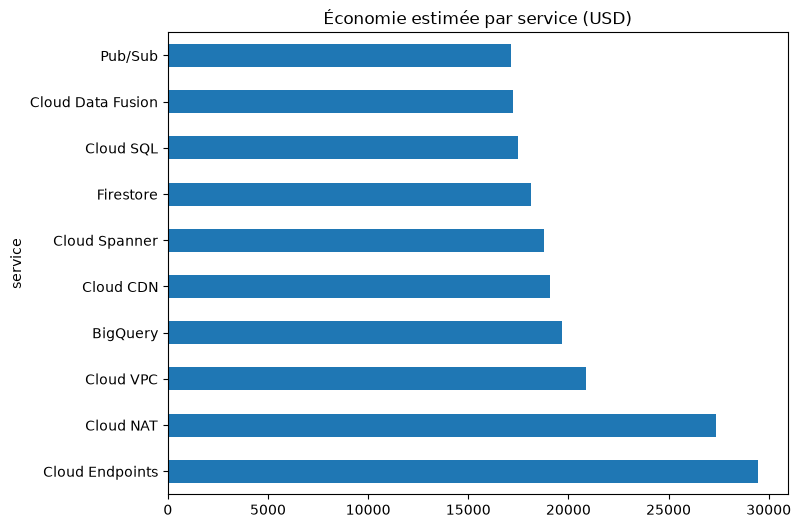

In [5]:
saving_by_service.head(10).plot(kind="barh", figsize=(8, 6), title="Économie estimée par service (USD)")

### Par région

In [6]:
saving_by_region = waste_candidates.groupby("region")["estimated_saving"].sum().sort_values(ascending=False)
saving_by_region

region
europe-north1              34977.958475
southamerica-east1         33472.605607
us-west1                   32876.948130
australia-southeast1       31508.945427
asia-southeast1            29486.759328
northamerica-northeast1    29361.931715
us-east1                   28668.139951
asia-northeast1            26147.232670
europe-west3               19489.155312
asia-east1                 15763.382343
europe-west1               11423.201128
us-central1                10939.675484
Name: estimated_saving, dtype: float64

<Axes: title={'center': 'Économie estimée par région (USD)'}, ylabel='region'>

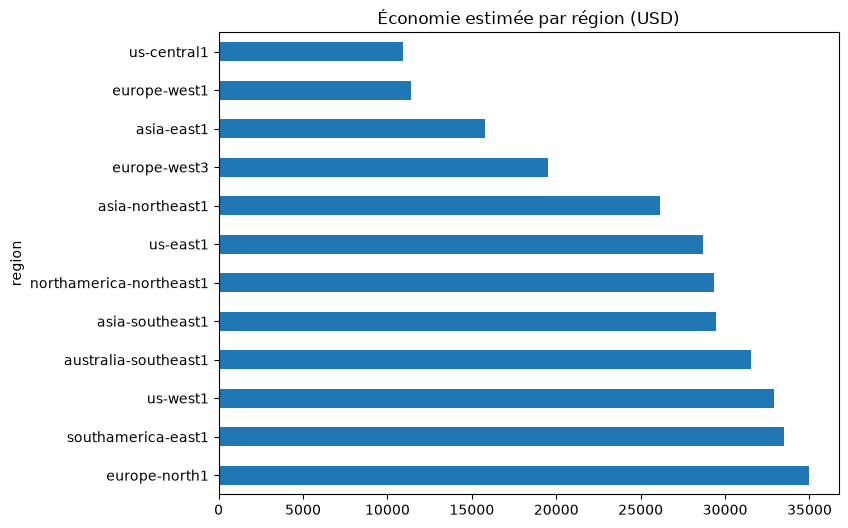

In [7]:
saving_by_region.plot(kind="barh", figsize=(8, 6), title="Économie estimée par région (USD)")

## 5. Plan d'action

Trié par économie estimée : les ressources où agir rapporte le plus.

In [8]:
action_plan = waste_candidates.sort_values("estimated_saving", ascending=False)[
    ["resource_id", "service", "region", "cost_usd", "cpu_util_pct", "memory_util_pct", "estimated_saving"]
]
action_plan.head(10)

,resource_id,service,region,cost_usd,cpu_util_pct,memory_util_pct,estimated_saving
240,res-LWGX075A,Cloud Dataproc,southamerica-east1,8832.79,7.35,60.67,8183.579935
859,res-723DJQ6D,Cloud Data Fusion,asia-northeast1,8693.36,7.96,10.82,8001.368544
548,res-RUL6UJ2I,Cloud NAT,asia-southeast1,8750.60,8.79,61.74,7981.422260
268,res-QZVTIOPY,Cloud Storage,asia-east1,8437.53,17.08,91.07,6996.399876
444,res-C7QGGDW5,BigQuery,europe-west3,7498.58,10.40,68.25,6718.727680
762,res-R6V5BB2L,Cloud Load Balancing,northamerica-northeast1,6731.94,1.32,59.95,6643.078392
556,res-YVDZ7Y3W,Cloud CDN,australia-southeast1,7049.61,6.97,29.33,6558.252183
887,res-AJJX91AK,Cloud Spanner,europe-north1,6824.82,7.34,6.22,6323.878212
594,res-7LLUZT3G,Cloud Endpoints,europe-north1,7989.93,21.58,24.91,6265.703106
744,res-72P7USQ6,Cloud SQL,europe-north1,6771.69,7.50,81.05,6263.813250


## 6. Sauvegarde

In [9]:
output_path = "../data/processed/waste_action_plan.csv"
action_plan.to_csv(output_path, index=False)
print(f"Saved {len(action_plan)} rows to {output_path}")

Saved 66 rows to ../data/processed/waste_action_plan.csv


## Synthèse

- Économie estimée : environ **304 000 USD**, soit **14 %** de la facture totale
- Gaspillage réparti partout : 18 services et les 12 régions sont touchés
- Plus gros postes côté services : **Cloud Endpoints**, **Cloud NAT**, **Cloud VPC**
- Plus gros postes côté régions : **europe-north1**, **southamerica-east1**, **us-west1**
- Ressource à traiter en premier : `res-LWGX075A` (Cloud Dataproc), 8 833 USD pour 7 % de CPU
- Livrable : `data/processed/waste_action_plan.csv`